In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import glob
sns.set_context("paper", font_scale=1.5)
sns.set_theme(style="ticks")

In [2]:
# Validation runs were done on Compute Canada clusters. We provide the code to run the 
# experiments and the results in extra/sweeps/hemo

# The preprocessed data can be generated by running the scripts in '../extra/data_preprocessing/hematopoiesis/' 
# or downloaded from the archive at https://doi.org/10.5281/zenodo.20723235. The code used to run the PBA analysis is
# also available in this archive.

In [3]:
# Load T validation results
results_dir = f'../sweeps/hemo/sweep_res/integrated_T_validation'
results_files = glob.glob(f'{results_dir}/*.csv')
pre_res = pd.DataFrame()
post_res = pd.DataFrame()
for f in results_files:
    if 'prenatal' in f:
        pre_res = pd.concat([pre_res, pd.read_csv(f, index_col=0)], ignore_index=True) 
    elif 'postnatal' in f:
        post_res = pd.concat([post_res, pd.read_csv(f, index_col=0)], ignore_index=True)

In [4]:
# Load n validation results
results_dir_n = f'../sweeps/hemo/sweep_res/integrated_n_validation'
results_files_n = glob.glob(f'{results_dir_n}/*.csv')

pre_res_n = pd.DataFrame()
post_res_n = pd.DataFrame()
for f in results_files_n:
    if 'prenatal' in f:
        pre_res_n = pd.concat([pre_res_n, pd.read_csv(f, index_col=0)], ignore_index=True) 
    elif 'postnatal' in f:
        post_res_n = pd.concat([post_res_n, pd.read_csv(f, index_col=0)], ignore_index=True)

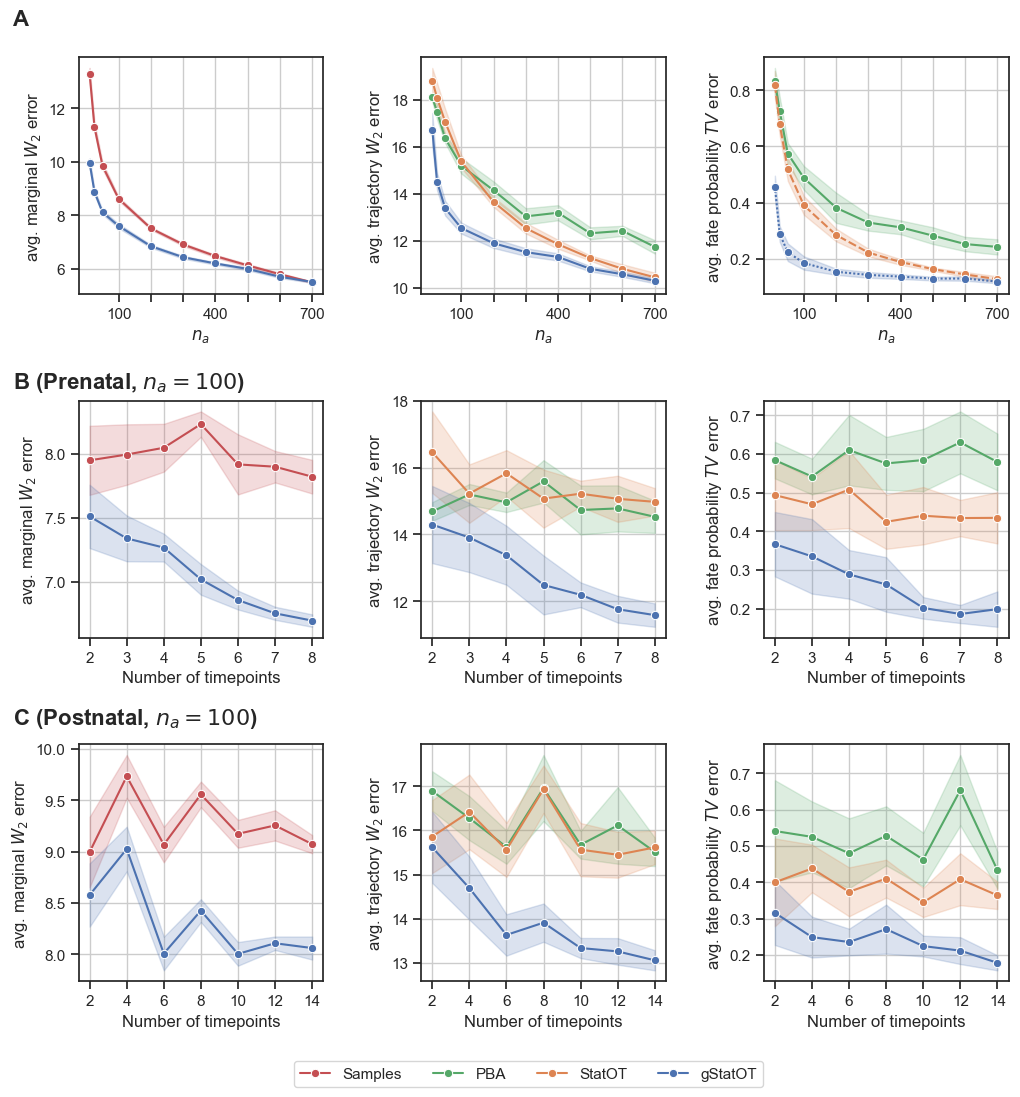

In [5]:
pre_res['Age range'] = 'Prenatal'
post_res['Age range'] = 'Postnatal'

all_pd = pd.concat([pre_res, post_res], ignore_index=True)

sub_res = all_pd.copy()

methods = ["Samples", "StatOT", "gStatOT", "PBA"]
palette = {methods[0]: sns.color_palette("deep", n_colors=4)[3],
           methods[1]: sns.color_palette("deep", n_colors=4)[1],
           methods[2]: sns.color_palette("deep", n_colors=4)[0],
           methods[3]: sns.color_palette("deep", n_colors=4)[2]}

x_label = 'Number of timepoints'
x_ticks_3 = np.arange(2, 15, 2, dtype=int)
x_ticks_2 = np.arange(2, 9, 1, dtype=int)
l = 4
fig, axes = plt.subplots(3, 3, figsize=(3 * l , 3 * l), sharex='row', 
                         gridspec_kw={'hspace': 0.45, 'wspace': 0.4})

ax1 = axes[1, 0]
ax2 = axes[1, 1]
ax3 = axes[1, 2]

ax4 = axes[2, 0]
ax5 = axes[2, 1]
ax6 = axes[2, 2]

N_df_W2 = sub_res.groupby(['method', 'T', 'experiment', 'Age range'], as_index=False)['marginal_W2_dist'].mean()
N_df_W2.loc[N_df_W2['method'] == 'StatOT', 'method'] = 'Samples'
N_df_W2 = N_df_W2[N_df_W2['method'] != 'PBA']

N_df_W2_pre = N_df_W2[N_df_W2['Age range'] == 'Prenatal']
N_df_W2_post = N_df_W2[N_df_W2['Age range'] == 'Postnatal']
# change statOT method to samples in N_df_W2
sns.lineplot(N_df_W2_pre, x='T', y='marginal_W2_dist', hue='method',
             ax=ax1, palette=palette, marker='o', errorbar='sd')
sns.lineplot(N_df_W2_post, x='T', y='marginal_W2_dist', hue='method',
             ax=ax4, palette=palette, marker='o', errorbar='sd')
ax1.set_ylabel(r'avg. marginal $W_2$ error')
ax4.set_ylabel(r'avg. marginal $W_2$ error')
ax1.set_xticks(x_ticks_2)
ax4.set_xticks(x_ticks_3)

ax1.set_xlabel(x_label)
ax4.set_xlabel(x_label)
ax1.legend().remove()
ax4.legend().remove()
ax1.grid()
ax4.grid()

N_df_W2 = sub_res.groupby(['method', 'T', 'experiment', 'Age range'], as_index=False)[
    'traj_W2_dist'].mean()
N_df_W2_pre = N_df_W2[N_df_W2['Age range'] == 'Prenatal']
N_df_W2_post = N_df_W2[N_df_W2['Age range'] == 'Postnatal']

sns.lineplot(N_df_W2_pre, x='T', y='traj_W2_dist', hue='method',
             ax=ax2, palette=palette, marker='o', errorbar='sd')
sns.lineplot(N_df_W2_post, x='T', y='traj_W2_dist', hue='method',
             ax=ax5, palette=palette, marker='o', errorbar='sd')
ax2.set_ylabel(r'avg. trajectory $W_2$ error')
ax5.set_ylabel(r'avg. trajectory $W_2$ error')
ax2.legend().set_visible(False)
ax5.legend().set_visible(False)
ax2.set_xlabel(x_label)
ax5.set_xlabel(x_label)
ax2.grid()
ax5.grid()

N_df_Blin = sub_res.groupby(['method', 'T', 'experiment', 'Age range'], as_index=False)['FP_TV_dist'].mean()
N_df_Blin_pre = N_df_Blin[N_df_Blin['Age range'] == 'Prenatal']
N_df_Blin_post = N_df_Blin[N_df_Blin['Age range'] == 'Postnatal']
sns.lineplot(N_df_Blin_pre, x='T', y='FP_TV_dist', hue='method',
             ax=ax3, palette=palette, marker='o', errorbar='sd')
sns.lineplot(N_df_Blin_post, x='T', y='FP_TV_dist', hue='method',
             ax=ax6, palette=palette, marker='o', errorbar='sd')
ax3.set_ylabel(r'avg. fate probability $TV$ error')
ax6.set_ylabel(r'avg. fate probability $TV$ error')
ax3.legend().set_visible(False)
ax6.legend().set_visible(False)
ax3.set_xlabel(x_label)
ax6.set_xlabel(x_label)
ax3.grid()
ax6.grid()


###### 
pre_res_n = pre_res_n.copy()
post_res_n = post_res_n.copy()

all_pd_n = pd.concat([pre_res_n, post_res_n], ignore_index=True)

sub_res = all_pd_n.copy()
sub_res['method'] = sub_res['method'].replace(
    to_replace=r'gStatOT.*', value='gStatOT', regex=True)
sub_res['method'] = sub_res['method'].replace(
    to_replace=r'StatOT_e.*', value='StatOT', regex=True)

ax1 = axes[0, 0]
ax2 = axes[0, 1]
ax3 = axes[0, 2]
ax1.set_xlabel(r'$n_a$')
ax2.set_xlabel(r'$n_a$')
ax3.set_xlabel(r'$n_a$')

n_vals = ['100', '', '', '400', '', '', '700']
n_ticks = [100, 200, 300, 400, 500, 600, 700]
N_df_W2 = sub_res.groupby(['method', 'n', 'experiment'], as_index=False)['marginal_W2_dist'].mean()
N_df_W2.loc[N_df_W2['method'] == 'StatOT', 'method'] = 'Samples'
N_df_W2 = N_df_W2[N_df_W2['method'] != 'PBA']

sns.lineplot(N_df_W2, x='n', y='marginal_W2_dist', hue='method',
             ax=ax1, palette=palette, marker='o', errorbar='sd')

ax1.set_ylabel(r'avg. marginal $W_2$ error')

ax1.set_xticks(n_ticks)
ax1.set_xticklabels(n_vals)
ax1.legend().remove()
ax1.grid()

N_df_W2_traj = sub_res.groupby(['method', 'n', 'experiment'], as_index=False)[
    'traj_W2_dist'].mean()

sns.lineplot(N_df_W2_traj, x='n', y='traj_W2_dist', hue='method',
             ax=ax2, palette=palette, marker='o', errorbar='sd')
ax2.set_ylabel(r'avg. trajectory $W_2$ error')
ax2.set_xticks(n_ticks)
ax2.set_xticklabels(n_vals)
ax2.legend().set_visible(False)
ax2.grid()

N_df_Blin = sub_res.groupby(['method', 'n', 'experiment'], as_index=False)['FP_TV_dist'].mean()
sns.lineplot(N_df_Blin, x='n', y='FP_TV_dist', hue='method',
             ax=ax3, palette=palette, marker='o', style='method', errorbar='sd')
ax3.set_ylabel(r'avg. fate probability $TV$ error')
ax3.set_xticks(n_ticks)
ax3.set_xticklabels(n_vals)
ax3.legend().set_visible(False)
ax3.grid()

fig.text(0.07, 0.92, "A", fontsize=16, fontweight='bold', va='top', ha='left')
fig.text(0.07, 0.62, r"B (Prenatal, $n_a = 100$)", fontsize=16, fontweight='bold', va='top', ha='left')
fig.text(0.07, 0.34, r"C (Postnatal, $n_a = 100$)", fontsize=16, fontweight='bold', va='top', ha='left')

handles, labels = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
all_handles = handles[0:1] + handles2
all_labels = labels[0:1] + labels2
fig.legend(all_handles, all_labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.05),
    ncols=5
)

plt.savefig('../figures/plots/figure_6.png', bbox_inches='tight', dpi=450)

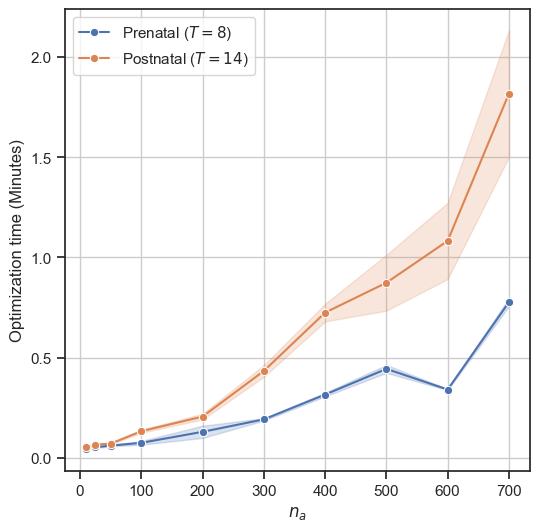

In [6]:
# plot optimizaiton time vs n
pre_n_gsot = pre_res_n[pre_res_n['method'] == 'gStatOT'].copy()
post_n_gsot = post_res_n[post_res_n['method'] == 'gStatOT'].copy()
pre_n_gsot['opt_time'] = pre_n_gsot['optimization time'].apply(lambda x: x.split(' ')[0]).astype(float)
post_n_gsot['opt_time'] = post_n_gsot['optimization time'].apply(lambda x: x.split(' ')[0]).astype(float)



fig, ax = plt.subplots(1, 1, figsize=(6, 6), sharey=True)

sns.lineplot(pre_n_gsot, x='n', y='opt_time', ax=ax, marker='o', label=r'Prenatal ($T = 8$)', errorbar='sd')
sns.lineplot(post_n_gsot, x='n', y='opt_time', ax=ax, marker='o', label=r'Postnatal ($T = 14$)', errorbar='sd')
n_vals = np.unique(post_n_gsot['n'])
ax.set_ylabel('Optimization time (Minutes)')
ax.set_xlabel(r'$n_a$')
ax.grid()
plt.savefig('../figures/plots/figure_6_n_opt_time.png', bbox_inches='tight', dpi=350)